# 神经网络

## 单层感知器
### 感知器学习规则
$$
f是sign函数，\eta表示学习率，t表示正确的标签 \\
y = f(\sum_{i=1}^n x_i \cdot w_i \\
\Delta w_i = \eta(t-y)x_i \\
\Delta w_i = \pm 2\eta x_i \\
w_i = w_i + \Delta w_i
$$
### 模型收敛条件

- 误差小于某个预先设定的较小的值
- 两次迭代之间的权值变化已经很小
- 设定最大迭代次数，当迭代超过最大次数就停止

### 无法处理异或问题


## 单层感知器
> 假设平面坐标系上有四个点,(3,3),(4,3)这两个点的标签为1，(1,1),(0,2)这两个点的标签为-1，构建神经网络来分类

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [15]:
X = np.array([
              [1,3,3],
              [1,4,3],
              [1,1,1],
              [1,0,2]
])
Y = np.array([
              [1],
              [1],
              [-1],
              [-1]
])
# 权值初始化
W = (np.random.random([3,1])-0.5)*2
print(W)
lr = 0.11
# 神经网络输出
O = 0
def update():
  global X,Y,W,lr
  O = np.sign(np.dot(X,W))
  W_C = lr * (X.T.dot(Y-O))/int(X.shape[0])
  W += W_C

[[ 0.465638  ]
 [-0.66492539]
 [ 0.92340464]]


Finished
epoch: 13


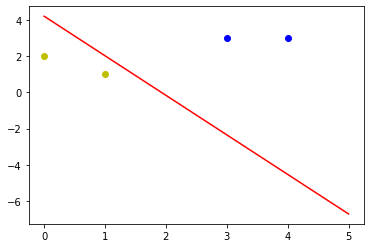

In [16]:
for i in range(100):
  update()
  O = np.sign(np.dot(X,W))
  if (O==Y).all():
    print("Finished")
    print("epoch:", i)
    break

x1 = [3,4]
y1 = [3,3]

x2 = [1,0]
y2 = [1,2]

k = -W[1]/W[2]
d = -W[0]/W[2]
xdata = (0,5)
plt.figure()
plt.plot(xdata, xdata*k+d, 'r')
plt.scatter(x1,y1,c='b')
plt.scatter(x2,y2,c='y')
plt.show()

## 线性神经网络
结构上与感知器非常相似，只是激活函数不同，在模型训练时把原来的sign函数改成了purelin函数:y=x

In [22]:
X = np.array([
              [1,3,3],
              [1,4,3],
              [1,1,1],
              [1,0,2]
])
Y = np.array([
              [1],
              [1],
              [-1],
              [-1]
])
# 权值初始化
W = (np.random.random([3,1])-0.5)*2
print(W)
lr = 0.11
# 神经网络输出
O = 0
def update():
  global X,Y,W,lr
  O = np.dot(X,W)
  W_C = lr * (X.T.dot(Y-O))/int(X.shape[0])
  W += W_C

[[ 0.30970967]
 [ 0.90268846]
 [-0.4276387 ]]


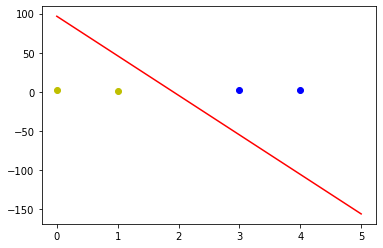

In [23]:
for i in range(100):
  update()
  O = np.dot(X,W)
  if (O==Y).all():
    print("Finished")
    print("epoch:", i)
    break

x1 = [3,4]
y1 = [3,3]

x2 = [1,0]
y2 = [1,2]

k = -W[1]/W[2]
d = -W[0]/W[2]
xdata = (0,5)
plt.figure()
plt.plot(xdata, xdata*k+d, 'r')
plt.scatter(x1,y1,c='b')
plt.scatter(x2,y2,c='y')
plt.show()

## Delta学习规则
$\delta$规则，也可以称为连续感知器学习规则

$\delta$学习规则是一种利用梯度下降法的一般性的学习规则

代价函数(损失函数)(Cost Function，Loss Function)

二次代价函数：
$$
E = \frac{1}{2} (t-y)^2 = \frac{1}{2}[t-f(WX)]^2
$$
误差E是权向量W的函数，可以使用梯度下降法来最小化E的值：
$$
\Delta W = -\eta E' = \eta X^T(t-y)f'(WX) = \eta X^T \delta \\
\Delta w_i = -\eta E' = \eta x_i(t-y)f'(WX) = \eta x_i \delta
$$

### 解决异或问题
1. 用两条直线实现异或逻辑
2. 对神经元添加非线性输入，从而引入非线性成分，但会使等效输入维度变大

In [38]:
X = np.array([
              [1,0,0,0,0,0],
              [1,0,1,0,0,1],
              [1,1,0,1,0,0],
              [1,1,1,1,1,1]
])
Y = np.array([
              -1,1,1,-1
])
# 权值初始化
W = (np.random.random(6)-0.5)*2
print(W)
lr = 0.11
# 神经网络输出
O = 0
def update():
  global X,Y,W,lr
  O = np.dot(X,W.T)
  W_C = lr * (Y-O.T).dot(X)/int(X.shape[0])
  W += W_C

[ 0.83554136 -0.36754239 -0.47354541  0.07965244 -0.64408495 -0.67999491]


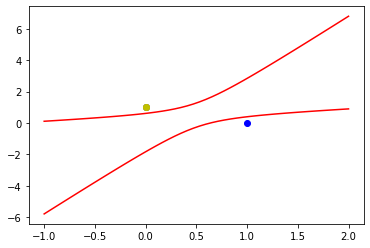

In [47]:
for _ in range(2000):
  update()
  # O = np.dot(X,W)
  # if (O==Y).all():
  #   print("Finished")
  #   print("epoch:", i)
  #   break

x1 = [0,1]
y1 = [1,0]

x2 = [0,0]
y2 = [1,1]

def calculate(x, root):
  a = W[5]
  b = W[2] + x*W[4]
  c = W[0] + x*W[1] + x*x*W[3]
  if root==1:
    return (-b + np.sqrt(b*b-4*a*c))/(2*a)
  if root==2:
    return (-b - np.sqrt(b*b-4*a*c))/(2*a)
xdata = np.linspace(-1,2)
plt.figure()
plt.plot(xdata, calculate(xdata, 1), 'r')
plt.plot(xdata, calculate(xdata, 2), 'r')
plt.plot(x1,y1,'bo')
plt.plot(x2,y2,'yo')
plt.show()

In [48]:
np.dot(X,W.T) 

array([-1.,  1.,  1., -1.])

## BP(Back Propagation)神经网络
$$
\delta^l:第l层学习信号\\ \delta^L输出层学习信号\\ W^l：第l层权值\\ X^l：第l层输入信号 \\
E = \frac{1}{2}(t-y)^2 \\
\frac{\partial E}{\partial W^l} = -(X^l)^T \delta^l \\
\Delta W^l = - \eta \frac{\partial E}{\partial W^l} = \eta(X^l)^T \delta^l \\
\delta^L = (t-y)f'(x^LW^L) \\
\delta ^l = \delta^{l+1}(W^{l+1})^Tf'(X^lW^l)
$$

### 激活函数
- Sigmoid函数
$$
f(x) = \frac{1}{1+e^{-x}}
$$
- Tanh函数
$$
f(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}
$$
- Softsign函数
$$
f(x) = \frac{x}{1+|x|}
$$
- ReLu函数
$$
f(x) = max(0,x)
$$

## BP神经网络解决异或问题

In [53]:
X = np.array([
              [1,0,0],
              [1,0,1],
              [1,1,0],
              [1,1,1]
])
Y = np.array([
              [0,1,1,0]
])
# 权值初始化
V = np.random.random((3,4)) * 2 - 1
W = np.random.random((4,1)) * 2 - 1
print(V)
print(W)
lr = 0.11
def sigmoid(x):
  return 1 / (1+np.exp(-x))

def dsigmoid(x):
  return x*(1-x)

def update():
  global X,Y,W,V,lr
  L1 = sigmoid(np.dot(X,V)) # 隐藏层输出(4,4)
  L2 = sigmoid(np.dot(L1,W)) # 输出层输出(4,1)
  L2_delta = (Y.T - L2) * dsigmoid(L2)
  L1_delta = L2_delta.dot(W.T) * dsigmoid(L1)

  W_C = lr * L1.T.dot(L2_delta)
  V_C = lr * X.T.dot(L1_delta)
  W += W_C
  V += V_C

[[ 0.0591524   0.85853357 -0.28772693  0.0935887 ]
 [ 0.60036091 -0.57076501 -0.82663793 -0.6961982 ]
 [ 0.87323351  0.75961465 -0.47012158  0.80400924]]
[[-0.90432806]
 [-0.53904747]
 [-0.71184786]
 [ 0.29792876]]


In [57]:
for i in range(20000):
  update()
  if i%500 == 0:
    L1 = sigmoid(np.dot(X,V)) # 隐藏层输出(4,4)
    L2 = sigmoid(np.dot(L1,W)) # 输出层输出(4,1)
    print("Error:",np.mean(np.abs(Y.T-L2)))

def judge(x):
  if x>= 0.5:
    return 1
  else:
    return 0
for i in map(judge,L2):
  print(i) 

Error: 0.020461543749564236
Error: 0.020262730279942937
Error: 0.020069380932582575
Error: 0.019881253479642015
Error: 0.01969812034386724
Error: 0.01951976748476619
Error: 0.01934599338615768
Error: 0.019176608134399968
Error: 0.01901143257788323
Error: 0.01885029755947884
Error: 0.018693043214597423
Error: 0.018539518328350775
Error: 0.018389579746040628
Error: 0.01824309183184046
Error: 0.01809992597109285
Error: 0.017959960112144395
Error: 0.017823078344066618
Error: 0.017689170506998267
Error: 0.01755813183218087
Error: 0.01742986260905498
Error: 0.01730426787705519
Error: 0.0171812571399695
Error: 0.017060744100944422
Error: 0.01694264641639846
Error: 0.016826885467274066
Error: 0.016713386146206995
Error: 0.016602076659323076
Error: 0.016492888341493244
Error: 0.01638575548398156
Error: 0.016280615173518868
Error: 0.01617740714191942
Error: 0.016076073625436345
Error: 0.01597655923312039
Error: 0.015878810823511297
Error: 0.015782777389046793
Error: 0.01568840994762493
Error: 0.